## Ensemble Learning

In [1]:
from scipy.special import comb
import math


def ensemble_error(n_classifier, error):
    k_start = int(math.ceil(n_classifier / 2.0))
    probs = [
        comb(n_classifier, k) * error**k * (1 - error) ** (n_classifier - k)
        for k in range(k_start, n_classifier + 1)
    ]
    return sum(probs)


ensemble_error(
    n_classifier=11, error=0.25
)  # 11 classifier with individual error rate of 0.25

0.03432750701904297

---
#### Implementing a simple majority vote classifier

In [ ]:
from sklearn.base import BaseEstimator
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.base import clone
from sklearn.pipeline import _name_estimators  # type: ignore
import numpy as np
import operator

In [7]:
class MajorityVoteClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, classifiers, vote="classlabel", weights=None) -> None:
        self.classifiers = classifiers
        self.named_classifiers = {
            key: value for key, value in _name_estimators(classifiers)
        }
        self.vote = vote
        self.weights = weights

    def fit(self, X, y):
        if self.vote not in ("probability", "classlabel"):
            raise ValueError(
                f"vote must be 'probability' or 'classlabel'; got (vote={self.vote})"
            )

        if self.weights and len(self.weights) != len(self.classifiers):
            raise ValueError(
                f"Number of classifiers and weights must be equal"
                f"; got {len(self.weights)} weights,"
                f" {len(self.classifiers)} classifiers"
            )

        # Use LabelEncoder to ensure class labels start with 0, which
        # is important for np.argmax call in self.predict
        self.lablenc_ = LabelEncoder()
        self.lablenc_.fit(y)
        self.classes_ = self.lablenc_.classes_
        self.classifiers_ = []
        for clf in self.classifiers:
            fitted_clf = clone(clf).fit(X, self.lablenc_.transform(y))
            self.classifiers_.append(fitted_clf)
        return self

    def predict(self, X):
        if self.vote == "probability":
            maj_vote = np.argmax(self.predict_proba(X), axis=1)
        else:  # 'classlabel' vote
            #  Collect results from clf.predict calls
            predictions = np.asarray([clf.predict(X) for clf in self.classifiers_]).T

            maj_vote = np.apply_along_axis(
                lambda x: np.argmax(np.bincount(x, weights=self.weights)),
                axis=1,
                arr=predictions,
            )
        maj_vote = self.lablenc_.inverse_transform(maj_vote)
        return maj_vote

    def predict_proba(self, X):
        probas = np.asarray([clf.predict_proba(X) for clf in self.classifiers_])
        avg_proba = np.average(probas, axis=0, weights=self.weights)
        return avg_proba

    def get_params(self, deep=True):
        if not deep:
            return super().get_params(deep=False)
        else:
            out = self.named_classifiers.copy()
            for name, step in self.named_classifiers.items():
                for key, value in step.get_params(deep=True).items():
                    out[f"{name}__{key}"] = value
            return out

---
### Using the majority voting principle to make predictions

In [ ]:
from sklearn import datasets

iris = datasets.load_iris()
X, y = iris.data[50:, [1, 2]], iris.target[50:]
le = LabelEncoder()

y = le.fit_transform(y)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


clf1 = LogisticRegression(penalty="l2", C=0.001, solver="lbfgs", random_state=1)

clf2 = DecisionTreeClassifier(max_depth=1, criterion="entropy", random_state=0)

clf3 = KNeighborsClassifier(n_neighbors=1, p=2, metric="minkowski")

pipe1 = Pipeline([["sc", StandardScaler()], ["clf", clf1]])  # type: ignore
pipe2 = Pipeline([["nothing", "passthrough"], ["clf", clf2]])  # type: ignore
pipe3 = Pipeline([["sc", StandardScaler()], ["clf", clf3]])  # type: ignore

clf_labels = ["Logistic regression", "Decision tree", "KNN"]

print("10-fold cross validation:\n")
for clf, label in zip([pipe1, pipe2, pipe3], clf_labels):
    scores = cross_val_score(
        estimator=clf, X=X_train, y=y_train, cv=10, scoring="roc_auc"
    )
    print(f"ROC AUC: {scores.mean():.2f} (+/- {scores.std():.2f}) [{label}]")

10-fold cross validation:

ROC AUC: 0.94 (+/- 0.11) [Logistic regression]
ROC AUC: 0.89 (+/- 0.09) [Decision tree]
ROC AUC: 0.88 (+/- 0.12) [KNN]


In [18]:
mv_clf = MajorityVoteClassifier(classifiers=[pipe1, pipe2, pipe3])
clf_labels += ["Majority Voting"]

all_clf = [pipe1, pipe2, pipe3, mv_clf]
for clf, label in zip(all_clf, clf_labels):
    scores = cross_val_score(
        estimator=clf, X=X_train, y=y_train, cv=10, scoring="roc_auc"
    )
    print(f"ROC AUC: {scores.mean():.2f} (+/- {scores.std():.2f}) [{label}]")

ROC AUC: 0.94 (+/- 0.11) [Logistic regression]
ROC AUC: 0.89 (+/- 0.09) [Decision tree]
ROC AUC: 0.88 (+/- 0.12) [KNN]
ROC AUC: 0.97 (+/- 0.06) [Majority Voting]


---
### Evaluating and tuning the ensemble classifier

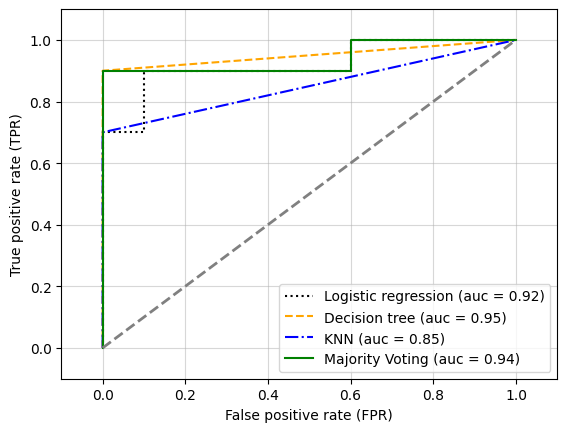

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from sklearn.metrics import auc


colors = ["black", "orange", "blue", "green"]
linestyles = [":", "--", "-.", "-"]
for clf, label, clr, ls in zip(all_clf, clf_labels, colors, linestyles):  # type: ignore
    # assuming the label of the positive class is 1
    y_pred = clf.fit(X_train, y_train).predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true=y_test, y_score=y_pred)
    roc_auc = auc(x=fpr, y=tpr)
    plt.plot(fpr, tpr, color=clr, linestyle=ls, label=f"{label} (auc = {roc_auc:.2f})")

plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=2)

plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.grid(alpha=0.5)
plt.xlabel("False positive rate (FPR)")
plt.ylabel("True positive rate (TPR)")

plt.show()

---
#### Hyper-parameter tuning

In [19]:
mv_clf.get_params()

{'pipeline-1': Pipeline(steps=[['sc', StandardScaler()],
                 ['clf', LogisticRegression(C=0.001, random_state=1)]]),
 'pipeline-2': Pipeline(steps=[['nothing', 'passthrough'],
                 ['clf',
                  DecisionTreeClassifier(criterion='entropy', max_depth=1,
                                         random_state=0)]]),
 'pipeline-3': Pipeline(steps=[['sc', StandardScaler()],
                 ['clf', KNeighborsClassifier(n_neighbors=1)]]),
 'pipeline-1__memory': None,
 'pipeline-1__steps': [['sc', StandardScaler()],
  ['clf', LogisticRegression(C=0.001, random_state=1)]],
 'pipeline-1__verbose': False,
 'pipeline-1__sc': StandardScaler(),
 'pipeline-1__clf': LogisticRegression(C=0.001, random_state=1),
 'pipeline-1__sc__copy': True,
 'pipeline-1__sc__with_mean': True,
 'pipeline-1__sc__with_std': True,
 'pipeline-1__clf__C': 0.001,
 'pipeline-1__clf__class_weight': None,
 'pipeline-1__clf__dual': False,
 'pipeline-1__clf__fit_intercept': True,
 'pipeline-1__

In [20]:
from sklearn.model_selection import GridSearchCV

params = {
    "pipeline-2__clf__max_depth": [1, 2],
    "pipeline-1__clf__C": [0.001, 0.1, 100.0],
}

grid = GridSearchCV(estimator=mv_clf, param_grid=params, cv=10, scoring="roc_auc")
grid.fit(X_train, y_train)

for r, _ in enumerate(grid.cv_results_["mean_test_score"]):
    mean_score = grid.cv_results_["mean_test_score"][r]
    std_dev = grid.cv_results_["std_test_score"][r]
    params = grid.cv_results_["params"][r]
    print(f"{mean_score:.3f} +/- {std_dev:.2f} {params}")

0.975 +/- 0.06 {'pipeline-1__clf__C': 0.001, 'pipeline-2__clf__max_depth': 1}
0.975 +/- 0.06 {'pipeline-1__clf__C': 0.001, 'pipeline-2__clf__max_depth': 2}
0.981 +/- 0.04 {'pipeline-1__clf__C': 0.1, 'pipeline-2__clf__max_depth': 1}
0.981 +/- 0.04 {'pipeline-1__clf__C': 0.1, 'pipeline-2__clf__max_depth': 2}
0.975 +/- 0.06 {'pipeline-1__clf__C': 100.0, 'pipeline-2__clf__max_depth': 1}
0.975 +/- 0.06 {'pipeline-1__clf__C': 100.0, 'pipeline-2__clf__max_depth': 2}


In [ ]:
print(f"Best parameters: {grid.best_params_}")
print(f"ROC AUC: {grid.best_score_:.2f}")

Best parameters: {'pipeline-1__clf__C': 0.1, 'pipeline-2__clf__max_depth': 1}
ROC AUC: 0.98


---
### Bagging (building an ensemble of classifiers from bootstrap samples)
- bootstrap samples =  (random samples with replacement)
- bagging is also known as bootstrap aggregating.

In [ ]:
import pandas as pd


df_wine = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data",
    header=None,
)

df_wine.columns = [
    "Class label",
    "Alcohol",
    "Malic acid",
    "Ash",
    "Alcalinity of ash",
    "Magnesium",
    "Total phenols",
    "Flavanoids",
    "Nonflavanoid phenols",
    "Proanthocyanins",
    "Color intensity",
    "Hue",
    "OD280/OD315 of diluted wines",
    "Proline",
]

# drop 1 class
df_wine = df_wine[df_wine["Class label"] != 1]

y = df_wine["Class label"].values
X = df_wine[["Alcohol", "OD280/OD315 of diluted wines"]].values

X[0:5]

array([[12.37,  1.82],
       [12.33,  1.67],
       [12.64,  1.59],
       [13.67,  2.46],
       [12.37,  2.87]])

In [24]:
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

In [55]:
from sklearn.ensemble import BaggingClassifier

tree = DecisionTreeClassifier(criterion="entropy", random_state=1, max_depth=3)

bag = BaggingClassifier(
    estimator=tree,
    n_estimators=500,
    max_samples=1.0,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    n_jobs=-1,
    random_state=1,
)

In [56]:
from sklearn.metrics import accuracy_score

tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)

print(f"Decision tree train/test accuracies {tree_train:.3f}/{tree_test:.3f}")

Decision tree train/test accuracies 0.926/0.875


In [57]:
bag = bag.fit(X_train, y_train)

y_train_pred = bag.predict(X_train)
y_test_pred = bag.predict(X_test)

bag_train = accuracy_score(y_train, y_train_pred)
bag_test = accuracy_score(y_test, y_test_pred)

print(f"Bagging train/test accuracies {bag_train:.3f}/{bag_test:.3f}")

Bagging train/test accuracies 0.979/0.917


In [ ]:
x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(nrows=1, ncols=2, sharex="col", sharey="row", figsize=(8, 3))


for idx, clf, tt in zip([0, 1], [tree, bag], ["Decision tree", "Bagging"]):
    clf.fit(X_train, y_train)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(
        X_train[y_train == 0, 0], X_train[y_train == 0, 1], c="blue", marker="^"
    )

    axarr[idx].scatter(
        X_train[y_train == 1, 0], X_train[y_train == 1, 1], c="green", marker="o"
    )

    axarr[idx].set_title(tt)

axarr[0].set_ylabel("OD280/OD315 of diluted wines", fontsize=12)

plt.tight_layout()
plt.text(
    0,
    -0.2,
    s="Alcohol",
    ha="center",
    va="center",
    fontsize=12,
    transform=axarr[1].transAxes,
)


plt.show()

---
### Leveraging weak learners via Adaptive Boosting

- In boosting, the ensemble consists of very simple base classifiers, also often referred to as weak learners, which often only have a slight performance advantage over random guessing.
- A typical example of a weak learner is a decision tree stump.

#### `AdaBoost`
-  AdaBoost uses the complete training
dataset to train the weak learners, where the training examples are reweighted in each iteration to
build a strong classifier that learns from the mistakes of the previous weak learners in the ensemble.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

stump = DecisionTreeClassifier(criterion="entropy", random_state=1, max_depth=1)
ada = AdaBoostClassifier(
    estimator=stump, n_estimators=500, learning_rate=0.1, random_state=1
)

In [ ]:
stump = stump.fit(X_train, y_train)
y_train_pred = stump.predict(X_train)
y_test_pred = stump.predict(X_test)

stump_train = accuracy_score(y_train, y_train_pred)
stump_test = accuracy_score(y_test, y_test_pred)

print(f"Decision stump train/test accuracies {stump_train:.3f}/{stump_test:.3f}")

Decision stump train/test accuracies 0.916/0.875


In [ ]:
ada = ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)

ada_train = accuracy_score(y_train, y_train_pred)
ada_test = accuracy_score(y_test, y_test_pred)

print(f"AdaBoost train/test accuracies {ada_train:.3f}/{ada_test:.3f}")

/home/slayer0x10/dev/ml/ml-study/.venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost train/test accuracies 1.000/0.917


/home/slayer0x10/dev/ml/ml-study/.venv/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


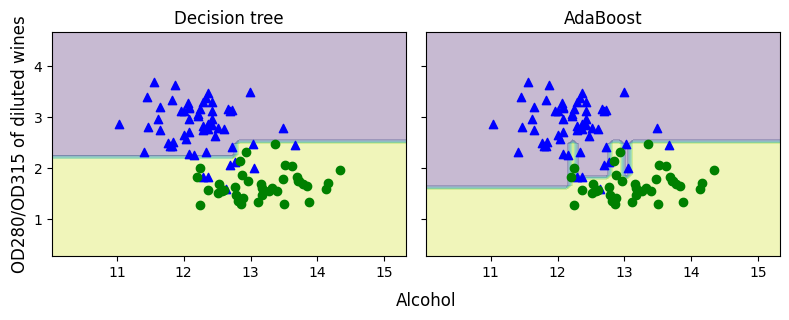

In [63]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(1, 2, sharex="col", sharey="row", figsize=(8, 3))


for idx, clf, tt in zip([0, 1], [tree, ada], ["Decision tree", "AdaBoost"]):
    clf.fit(X_train, y_train)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx].contourf(xx, yy, Z, alpha=0.3)
    axarr[idx].scatter(
        X_train[y_train == 0, 0], X_train[y_train == 0, 1], c="blue", marker="^"
    )
    axarr[idx].scatter(
        X_train[y_train == 1, 0], X_train[y_train == 1, 1], c="green", marker="o"
    )
    axarr[idx].set_title(tt)

axarr[0].set_ylabel("OD280/OD315 of diluted wines", fontsize=12)

plt.tight_layout()
plt.text(
    0,
    -0.2,
    s="Alcohol",
    ha="center",
    va="center",
    fontsize=12,
    transform=axarr[1].transAxes,
)


plt.show()

---
### `XGBoost`
- XGBoost proposed several tricks and approximations that speed up the training process substantially.
- Hence, the name XGBoost, which stands for extreme gradient boosting.

In [65]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    random_state=1,
)


gbm = model.fit(X_train, y_train)

y_train_pred = gbm.predict(X_train)
y_test_pred = gbm.predict(X_test)

gbm_train = accuracy_score(y_train, y_train_pred)
gbm_test = accuracy_score(y_test, y_test_pred)
print(f"XGboost train/test accuracies {gbm_train:.3f}/{gbm_test:.3f}")

XGboost train/test accuracies 0.968/0.917
